In [7]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Ensure TensorFlow 2.x compatibility
print(f"TensorFlow Version: {tf.__version__}")

# Define image size and batch size
IMG_SIZE = (48, 48)  # Increased for better feature extraction
BATCH_SIZE = 32
EPOCHS = 150  # Increased for better training

# Define data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Load data
train_data_dir = "data/train"
valid_data_dir = "data/test"

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical"
)

valid_generator = valid_datagen.flow_from_directory(
    valid_data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical"
)

# Get the number of classes
num_classes = len(train_generator.class_indices)
print(f"Detected {num_classes} classes: {train_generator.class_indices}")

# Define an improved CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')  # Output layer
])

# Compile the model with an optimized learning rate
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS
)

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the model in the new Keras format
model.save("models/drowsiness_model.keras")
print("Model saved successfully in 'models/drowsiness_model.keras'")


TensorFlow Version: 2.18.0
Found 2467 images belonging to 4 classes.
Found 433 images belonging to 4 classes.
Detected 4 classes: {'Closed': 0, 'Open': 1, 'no_yawn': 2, 'yawn': 3}
Epoch 1/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.3948 - loss: 2.0035 - val_accuracy: 0.2517 - val_loss: 1.9390
Epoch 2/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - accuracy: 0.5464 - loss: 1.1290 - val_accuracy: 0.2517 - val_loss: 3.3124
Epoch 3/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.5840 - loss: 1.0082 - val_accuracy: 0.2517 - val_loss: 4.0440
Epoch 4/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.6050 - loss: 0.8856 - val_accuracy: 0.2517 - val_loss: 3.6034
Epoch 5/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - accuracy: 0.6364 - loss: 0.8381 - val_accuracy: 0.3118 - val_loss: 1.8189
Epoch 6/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.6313 - loss: 0.7864 - val_accuracy: 0.6328 - val_loss: 0.8754
Epoch 7/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 9s 111

✅ Model Loaded Successfully!
Found 433 images belonging to 4 classes.
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8915 - loss: 0.2610

✅ Test Accuracy: 0.7852
✅ Test Loss: 0.4686
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step

🔹 Classification Report:

              precision    recall  f1-score   support

      Closed       0.97      1.00      0.99       109
        Open       1.00      0.96      0.98       109
     no_yawn       0.67      0.37      0.47       109
        yawn       0.55      0.81      0.66       106

    accuracy                           0.79       433
   macro avg       0.80      0.79      0.77       433
weighted avg       0.80      0.79      0.78       433



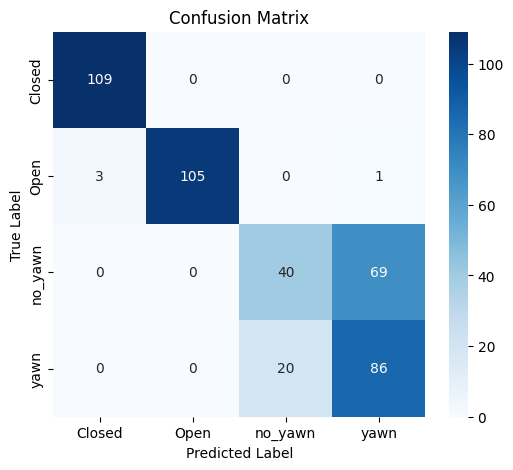

In [8]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the trained model
model_path = "models/drowsiness_model.keras"
model = load_model(model_path)
print("✅ Model Loaded Successfully!")

# Image size and batch size (same as used during training)
IMG_SIZE = (48, 48)
BATCH_SIZE = 32

# Data generator for evaluation
test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_data_dir = "data/test"  # Update path if test images are in a different folder

test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False  # Important: Keep shuffle=False for correct label mapping
)

# Evaluate the model
loss, accuracy = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {accuracy:.4f}")
print(f"✅ Test Loss: {loss:.4f}")

# Get predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())  # Class names

# Generate classification report
print("\n🔹 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
